C:\Users\Dell\AppData\Local\Temp\ipykernel_5444\3110569867.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='total_rec_prncp',x='sub_grade',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to sub_Grade")


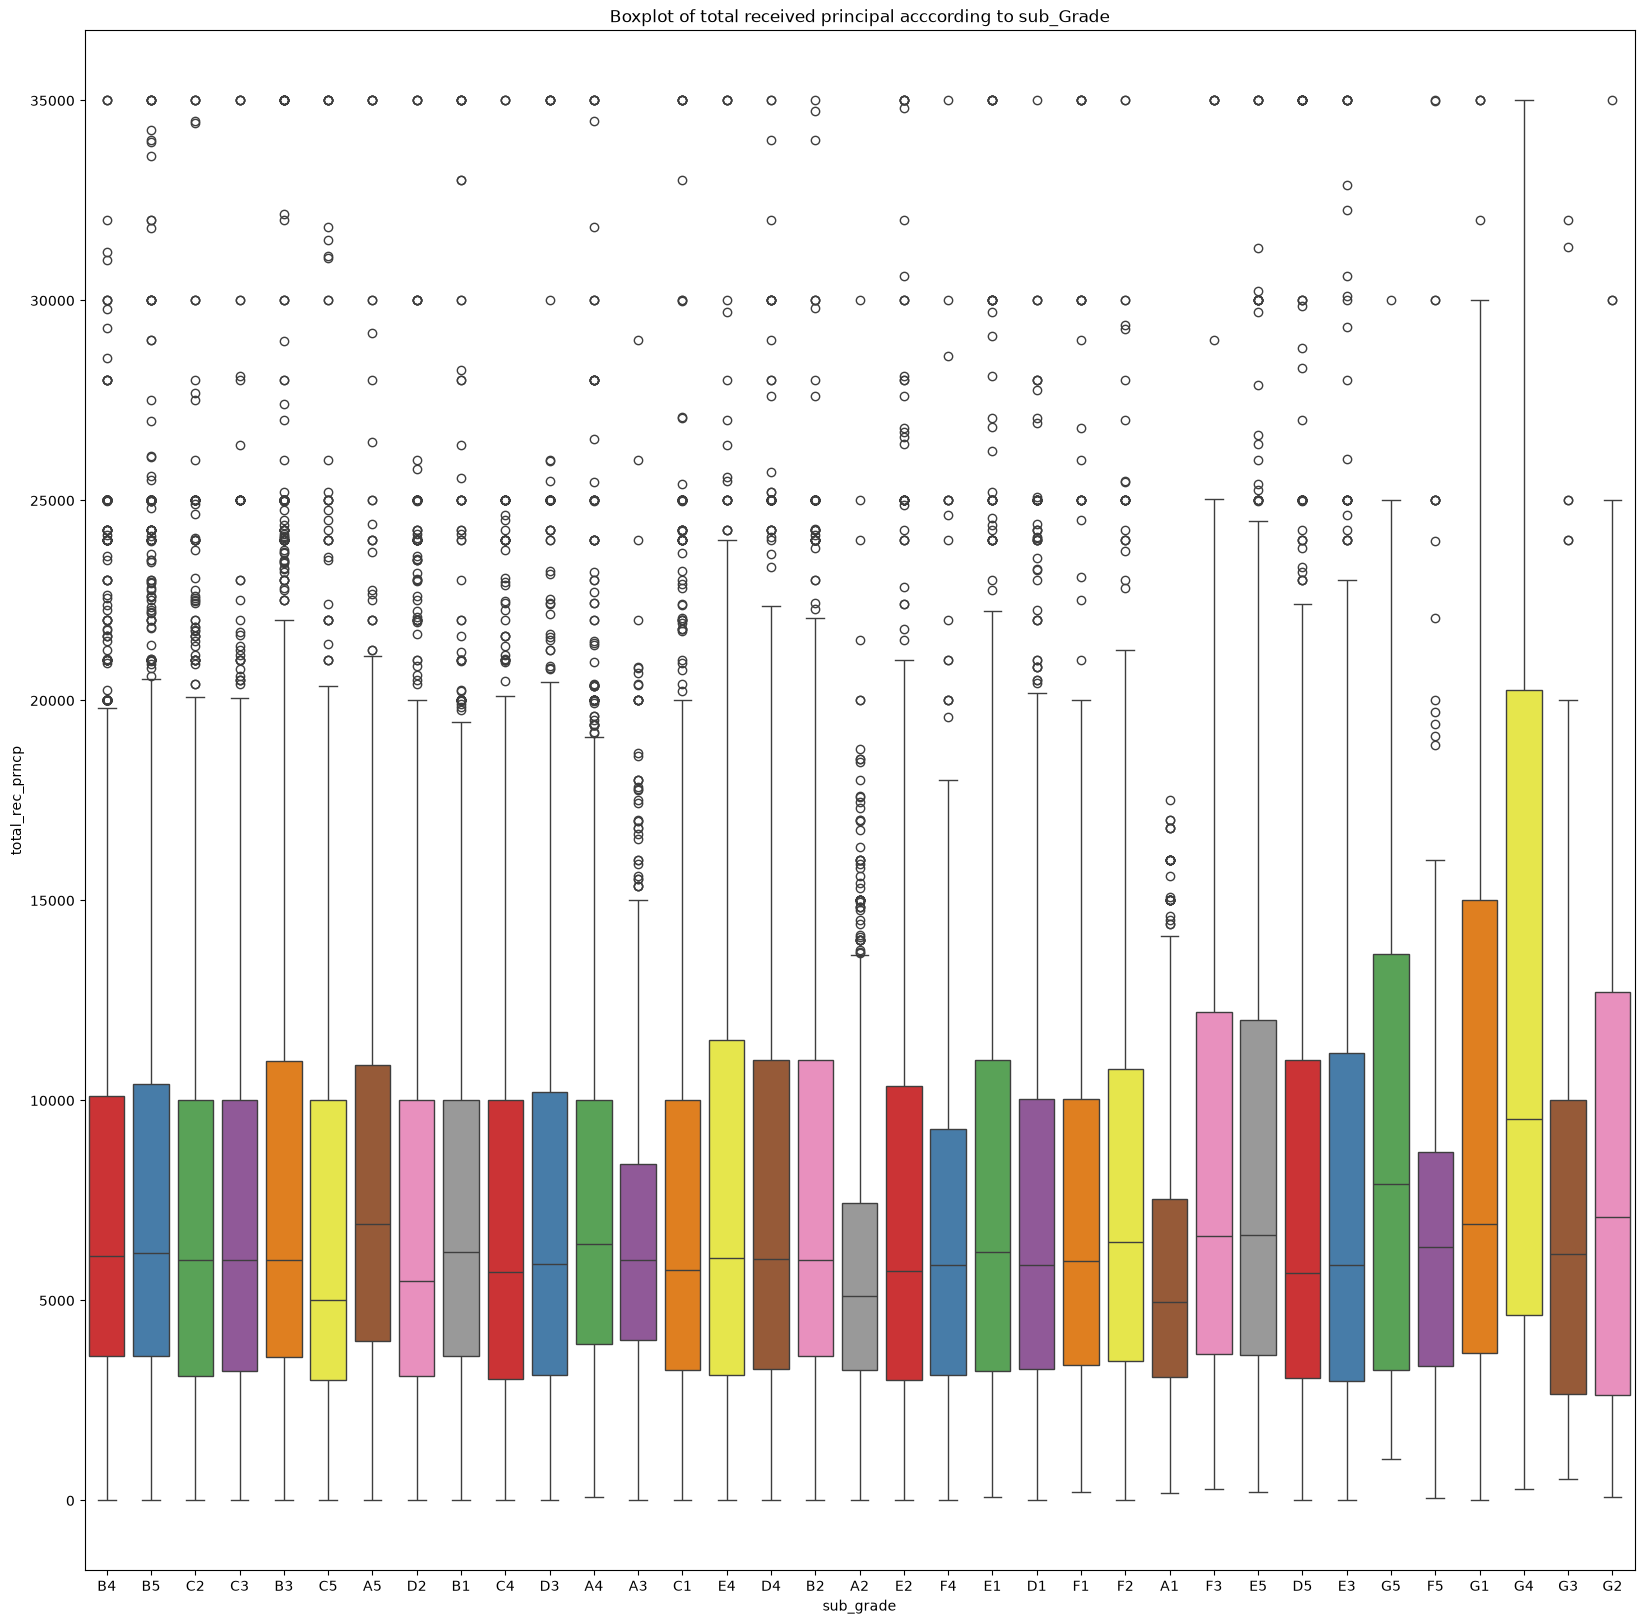

C:\Users\Dell\AppData\Local\Temp\ipykernel_5444\3110569867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='total_rec_prncp',x='grade',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to Grade")


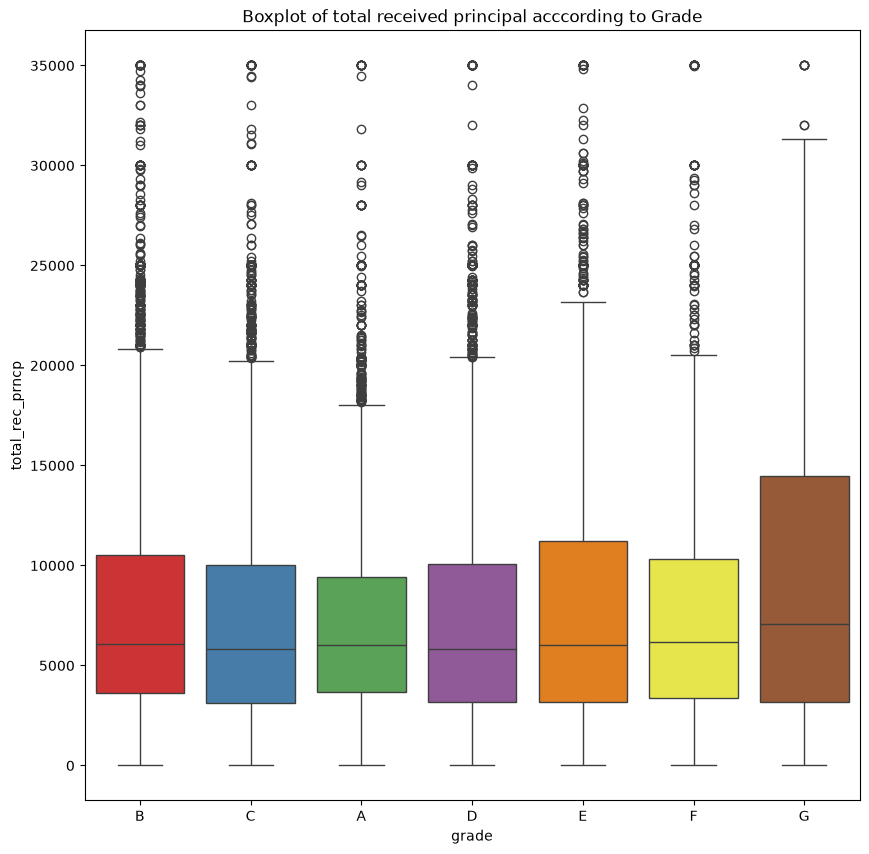

Number of unique values in emp_length: 11
Unique values: <ArrowStringArray>
[ '< 1 year', '10+ years',   '6 years',   '3 years',    '1 year',   '5 years',
   '9 years',   '2 years',   '4 years',   '8 years',   '7 years',         nan]
Length: 12, dtype: str
Number of unique values in H/O: 5
Unique values: <ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'NONE', 'OTHER']
Length: 5, dtype: str


C:\Users\Dell\AppData\Local\Temp\ipykernel_5444\3110569867.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='total_rec_prncp',x='delinq_2yrs',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to delinquency")


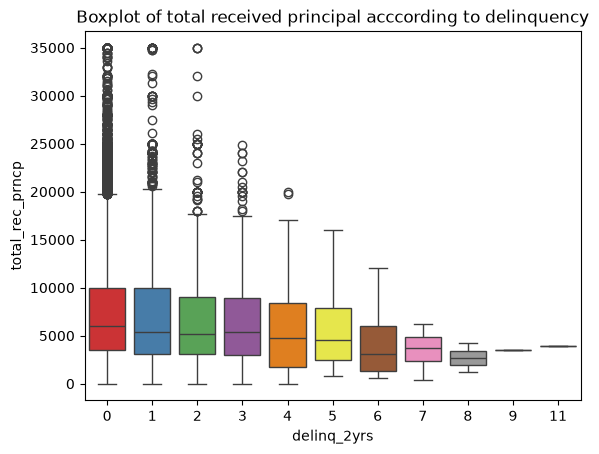

Correlation coefficient between annual income and total_rec_prncp: 0.2311306231578562
Correlation coefficient between dti and total_rec_prncp -0.009776045840785196
Correlation coefficient between delinq_2yrs and total_rec_prncp -0.03327796309527871
Correlation coefficient between fico_range_low and total_rec_prncp 0.149752096321234
Correlation coefficient between revolving utilization rate and total_rec_prncp -0.022209783176335617
Intercept: [-43423.24806232]
Coefficients: [[ 2.18804018e-02  4.86486747e+01 -4.45300802e+01  6.35331497e+01
   5.68765072e+02  4.47379104e+02  5.38795802e+02  5.67360338e+02
   6.46611823e+02  6.71726843e+02  3.61073798e+02  5.20776996e+02
   8.11924022e+02  8.75802817e+02  1.64631924e+02  1.60514924e+00
  -9.23653472e+00 -5.63515800e+02 -3.63362197e+02  3.02041878e+03
   3.74733097e+03  4.95129591e+03  5.32865972e+03  5.86217048e+03
   7.78171531e+03]]
R-squared: 0.08397380285404821
RMSE: 5689.896664880757


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Tue Sep  8 18:16:47 2026

@author: Dell
"""
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
pd.set_option('display.max_column',None)
file_p='C:\\Users\\Dell\\My Drive\\data\\Lending club data Python.xlsx'
d1=pd.read_excel(file_p)
plt.figure(figsize=(20, 20))
sns.boxplot(y='total_rec_prncp',x='sub_grade',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to sub_Grade")
plt.show()
plt.figure(figsize=(10, 10))
sns.boxplot(y='total_rec_prncp',x='grade',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to Grade")
plt.show()
print("Number of unique values in emp_length:", d1['emp_length'].nunique())
print("Unique values:",d1['emp_length'].unique())
print("Number of unique values in H/O:", d1['home_ownership'].nunique())
print("Unique values:",d1['home_ownership'].unique())
sns.boxplot(y='total_rec_prncp',x='delinq_2yrs',data=d1,palette='Set1').set(title="Boxplot of total received principal acccording to delinquency")
plt.show()
e_length=pd.get_dummies(d1['emp_length'],drop_first=True)
HO=pd.get_dummies(d1['home_ownership'], drop_first=True)
grade=pd.get_dummies(d1['grade'],drop_first=True)
d1.drop(['id','member_id','loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate','installment','grade','sub_grade','emp_name','emp_length','home_ownership','is_inc_v','accept_d','exp_d','list_d','issue_d','loan_status','pymnt_plan','url','desc','purpose','title','addr_city','addr_state','acc_now_delinq','acc_open_past_24mths','bc_open_to_buy','percent_bc_gt_75','bc_util','delinq_amnt','earliest_cr_line','fico_range_high','inq_last_6mths','mths_since_last_delinq','mths_since_last_record','mths_since_recent_inq','mths_since_recent_loan_delinq','mths_since_recent_revol_delinq','mths_since_recent_bc','mort_acc','open_acc','pub_rec_gt_100','pub_rec','total_bal_ex_mort','revol_bal','total_bc_limit','total_acc','initial_list_status','out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv','total_rec_int','total_rec_late_fee','last_pymnt_d','last_pymnt_amnt','next_pymnt_d','last_credit_pull_d','last_fico_range_high','last_fico_range_low'],axis=1,inplace=True)
d1=pd.concat([d1,e_length,HO,grade],axis=1)
d1 = d1.dropna(subset=['revol_util'])
cor1=d1['annual_inc'].corr(d1['total_rec_prncp'])
print("Correlation coefficient between annual income and total_rec_prncp:",cor1)
cor2=d1['dti'].corr(d1['total_rec_prncp'])
print("Correlation coefficient between dti and total_rec_prncp",cor2)
cor3=d1['delinq_2yrs'].corr(d1['total_rec_prncp'])
print("Correlation coefficient between delinq_2yrs and total_rec_prncp",cor3)
cor4=d1['fico_range_low'].corr(d1['total_rec_prncp'])
print("Correlation coefficient between fico_range_low and total_rec_prncp", cor4)
cor5=d1['revol_util'].corr(d1['total_rec_prncp'])
print("Correlation coefficient between revolving utilization rate and total_rec_prncp",cor5)
dep=pd.DataFrame(d1['total_rec_prncp'])
d1=d1.drop(['total_rec_prncp'],axis=1)
d1=d1.apply(pd.to_numeric)
dep=dep.apply(pd.to_numeric)
X_train,X_test,y_train, y_test=train_test_split(d1,dep,test_size=0.2,random_state=36)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Intercept:",model.intercept_)
print("Coefficients:", model.coef_)
print("R-squared:", r2_score(y_test,y_pred))
rmse=mean_squared_error(y_test,y_pred)**0.5
print("RMSE:",rmse)

